In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset

In [2]:
# Load the job dataset
df = pd.read_csv('dataset/naukri_com-job_sample.csv', encoding='utf-8', on_bad_lines='skip')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")

Dataset Shape: (22000, 14)
Total Records: 22000
Total Features: 14


## 2. Initial Data Exploration

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,company,education,experience,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,payrate,postdate,site_name,skills,uniq_id
0,MM Media Pvt Ltd,"UG: B.Tech/B.E. - Any Specialization PG:Any Postgraduate - Any Specialization, Post Graduation N...",0 - 1 yrs,Media / Entertainment / Internet,Job Description Send me Jobs like this Qualifications: - == > 10th To Graduation & Any Skill: ...,210516002263,Chennai,Walkin Data Entry Operator (night Shift),NaN,"1,50,000 - 2,25,000 P.A",2016-05-21 19:30:00 +0000,NaN,ITES,43b19632647068535437c774b6ca6cf8
1,find live infotech,UG: B.Tech/B.E. - Any Specialization PG:MBA/PGDM - Any Specialization,0 - 0 yrs,Advertising / PR / MR / Event Management,Job Description Send me Jobs like this Qualifications: - == > 10th To Graduation & Any Skill: ...,210516002391,Chennai,Work Based Onhome Based Part Time.,60.0,"1,50,000 - 2,50,000 P.A. 20000",2016-05-21 19:30:00 +0000,NaN,Marketing,d4c72325e57f89f364812b5ed5a795f0
2,Softtech Career Infosystem Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any Postgraduate Doctorate:Doctorate Not Required,4 - 8 yrs,IT-Software / Software Services,Job Description Send me Jobs like this - as a developer in providing application design guidan...,101016900534,Bengaluru,Pl/sql Developer - SQL,NaN,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,IT Software - Application Programming,c47df6f4cfdf5b46f1fd713ba61b9eba
3,Onboard HRServices LLP,UG: Any Graduate - Any Specialization PG:CA Doctorate:Doctorate Not Required,11 - 15 yrs,Banking / Financial Services / Broking,"Job Description Send me Jobs like this - Involved with all stages of indirect taxation, includ...",81016900536,"Mumbai, Bengaluru, Kolkata, Chennai, Coimbatore, Tamilnadu",Manager/ad/partner - Indirect Tax - CA,NaN,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,Accounts,115d28f140f694dd1cc61c53d03c66ae
4,Spire Technologies and Solutions Pvt. Ltd.,"UG: B.Tech/B.E. - Any Specialization PG:Any Postgraduate - Any Specialization, MCA - Computers, ...",6 - 8 yrs,IT-Software / Software Services,Job Description Send me Jobs like this Please share your Resume on : regina.mary@spire2grow.co...,120916002122,Bengaluru,JAVA Technical Lead (6-8 yrs) -,4.0,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,IT Software - Application Programming,a12553fc03bc7bcced8b1bb8963f97b4


In [4]:
# Display basic information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              21996 non-null  object 
 1   education            20004 non-null  object 
 2   experience           21996 non-null  object 
 3   industry             21995 non-null  object 
 4   jobdescription       21996 non-null  object 
 5   jobid                22000 non-null  int64  
 6   joblocation_address  21499 non-null  object 
 7   jobtitle             22000 non-null  object 
 8   numberofpositions    4464 non-null   float64
 9   payrate              21903 non-null  object 
 10  postdate             21977 non-null  object 
 11  site_name            3987 non-null   object 
 12  skills               21472 non-null  object 
 13  uniq_id              22000 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.3+ MB


In [5]:
# Display column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id']


In [6]:
# Check for missing values
print("Missing Values Summary:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data)

Missing Values Summary:
                 Column  Missing_Count  Missing_Percentage
11            site_name          18013               81.88
8     numberofpositions          17536               79.71
1             education           1996                9.07
12               skills            528                2.40
6   joblocation_address            501                2.28
9               payrate             97                0.44
10             postdate             23                0.10
2            experience              4                0.02
0               company              4                0.02
3              industry              5                0.02
4        jobdescription              4                0.02


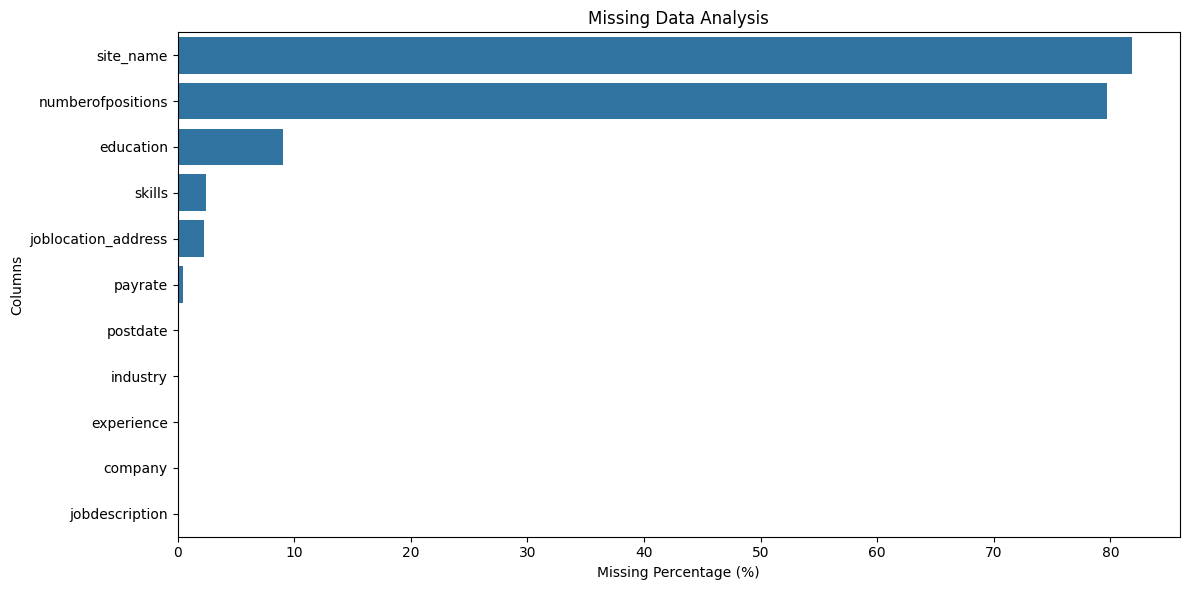

In [7]:
# Visualize missing data
plt.figure(figsize=(12, 6))
missing_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percentages = missing_percentages[missing_percentages > 0]
sns.barplot(x=missing_percentages.values, y=missing_percentages.index)
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Columns')
plt.title('Missing Data Analysis')
plt.tight_layout()
plt.show()

## 3. Data Cleaning Steps

### 3.1 Remove Duplicates

In [8]:
# Check for duplicate rows
print(f"Total Duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate Rows by jobid: {df['jobid'].duplicated().sum()}")

# Remove duplicates based on jobid
df_clean = df.drop_duplicates(subset=['jobid'], keep='first')
print(f"\nRows after removing duplicates: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Total Duplicate Rows: 0
Duplicate Rows by jobid: 90

Rows after removing duplicates: 21910
Rows removed: 90


### 3.2 Handle Missing Values

In [9]:
# Create a copy for cleaning
df_clean = df_clean.copy()

# Fill missing values based on column type
# For text columns, fill with 'Not Specified'
text_columns = ['company', 'education', 'industry', 'jobdescription', 'joblocation_address', 
                'jobtitle', 'skills', 'site_name']

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Not Specified')

# For experience, fill with '0 - 0 yrs'
if 'experience' in df_clean.columns:
    df_clean['experience'] = df_clean['experience'].fillna('0 - 0 yrs')

# For payrate, fill with 'Not Disclosed by Recruiter'
if 'payrate' in df_clean.columns:
    df_clean['payrate'] = df_clean['payrate'].fillna('Not Disclosed by Recruiter')

# For numberofpositions, fill with empty string or 0
if 'numberofpositions' in df_clean.columns:
    df_clean['numberofpositions'] = df_clean['numberofpositions'].fillna('')

print("Missing values handled successfully!")
print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

Missing values handled successfully!

Remaining missing values: 23


### 3.3 Clean Text Data

In [10]:
# Function to clean text
def clean_text(text):
    if pd.isna(text) or text == 'Not Specified':
        return text
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', str(text))
    # Remove special characters but keep important punctuation
    text = re.sub(r'[^\w\s.,;:()\-/&]', '', text)
    return text.strip()

# Apply text cleaning to relevant columns
text_clean_columns = ['company', 'jobdescription', 'jobtitle', 'skills', 'education']
for col in text_clean_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_text)

print("Text data cleaned successfully!")

Text data cleaned successfully!


### 3.4 Parse and Clean Experience Field

In [11]:
# Extract minimum and maximum years of experience
def extract_experience(exp_str):
    if pd.isna(exp_str) or exp_str == '0 - 0 yrs':
        return 0, 0
    
    # Extract numbers from experience string
    numbers = re.findall(r'\d+', str(exp_str))
    
    if len(numbers) >= 2:
        return int(numbers[0]), int(numbers[1])
    elif len(numbers) == 1:
        return int(numbers[0]), int(numbers[0])
    else:
        return 0, 0

# Apply experience extraction
if 'experience' in df_clean.columns:
    df_clean[['min_experience', 'max_experience']] = df_clean['experience'].apply(
        lambda x: pd.Series(extract_experience(x))
    )
    print("Experience field parsed successfully!")
    print(f"Min Experience Range: {df_clean['min_experience'].min()} - {df_clean['min_experience'].max()}")
    print(f"Max Experience Range: {df_clean['max_experience'].min()} - {df_clean['max_experience'].max()}")

Experience field parsed successfully!
Min Experience Range: 0 - 26
Max Experience Range: 0 - 30


### 3.5 Parse Date Fields

In [12]:
# Convert postdate to datetime
if 'postdate' in df_clean.columns:
    df_clean['postdate'] = pd.to_datetime(df_clean['postdate'], errors='coerce')
    df_clean['post_year'] = df_clean['postdate'].dt.year
    df_clean['post_month'] = df_clean['postdate'].dt.month
    df_clean['post_day'] = df_clean['postdate'].dt.day
    print("Date fields parsed successfully!")
    print(f"Date Range: {df_clean['postdate'].min()} to {df_clean['postdate'].max()}")

Date fields parsed successfully!
Date Range: 2015-01-24 19:48:31+00:00 to 2017-01-11 21:00:00+00:00


### 3.6 Clean Location Data

In [13]:
# Extract primary location from joblocation_address
def extract_primary_location(location_str):
    if pd.isna(location_str) or location_str == 'Not Specified':
        return 'Not Specified'
    
    # Split by comma and take first location
    locations = str(location_str).split(',')
    return locations[0].strip() if locations else 'Not Specified'

if 'joblocation_address' in df_clean.columns:
    df_clean['primary_location'] = df_clean['joblocation_address'].apply(extract_primary_location)
    print("Location data cleaned successfully!")
    print(f"\nTop 10 Job Locations:")
    print(df_clean['primary_location'].value_counts().head(10))

Location data cleaned successfully!

Top 10 Job Locations:
primary_location
Bengaluru/Bangalore                   5876
Mumbai                                3633
Bengaluru                             2023
Chennai                               1722
Hyderabad / Secunderabad              1501
Delhi                                 1463
Noida                                 1265
Hyderabad                             1149
Gurgaon                               1097
Delhi/NCR(National Capital Region)     771
Name: count, dtype: int64


### 3.7 Extract Skills into List

In [14]:
# Convert skills string to list
def parse_skills(skills_str):
    if pd.isna(skills_str) or skills_str == 'Not Specified':
        return []
    
    # Split by common delimiters and clean
    skills = re.split(r'[,;|]', str(skills_str))
    skills = [skill.strip().lower() for skill in skills if skill.strip()]
    return skills

if 'skills' in df_clean.columns:
    df_clean['skills_list'] = df_clean['skills'].apply(parse_skills)
    df_clean['skills_count'] = df_clean['skills_list'].apply(len)
    print("Skills parsed successfully!")
    print(f"Average number of skills per job: {df_clean['skills_count'].mean():.2f}")

Skills parsed successfully!
Average number of skills per job: 0.98


### 3.8 Remove Outliers and Invalid Data

In [15]:
# Remove jobs with unrealistic experience requirements
df_clean = df_clean[df_clean['max_experience'] <= 50]  # Max 50 years experience

# Remove jobs with empty job titles or descriptions
df_clean = df_clean[df_clean['jobtitle'] != 'Not Specified']
df_clean = df_clean[df_clean['jobdescription'] != 'Not Specified']

# Remove very short job descriptions (likely spam or incomplete)
df_clean = df_clean[df_clean['jobdescription'].str.len() > 100]

print(f"Rows after removing outliers: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Rows after removing outliers: 21865
Rows removed: 135


## 4. Data Quality Check

In [16]:
# Check data quality after cleaning
print("=== Data Quality Summary ===")
print(f"Total Records: {len(df_clean)}")
print(f"Total Features: {len(df_clean.columns)}")
print(f"\nMissing Values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate Records: {df_clean.duplicated().sum()}")
print(f"\nData Types:")
print(df_clean.dtypes.value_counts())

=== Data Quality Summary ===
Total Records: 21865
Total Features: 22

Missing Values: 76


TypeError: unhashable type: 'list'

In [17]:
# Display cleaned dataset summary
print("\n=== Cleaned Dataset Summary ===")
df_clean.describe(include='all')


=== Cleaned Dataset Summary ===


,company,education,experience,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,payrate,postdate,site_name,skills,uniq_id,min_experience,max_experience,post_year,post_month,post_day,primary_location,skills_list,skills_count
count,21865,21865,21865,21865,21865,2.186500e+04,21865,21865,21865,21865,21846,21865,21865,21865,21865.000000,21865.000000,21846.000000,21846.000000,21846.000000,21865,21865,21865.000000
unique,8464,2353,147,64,21015,NaN,2320,17523,85,1847,NaN,2,46,21865,NaN,NaN,NaN,NaN,NaN,119,46,NaN
top,Indian Institute of Technology Bombay,"UG: Any Graduate - Any Specialization, Graduation Not Required PG:Any Postgraduate - Any Special...",2 - 7 yrs,IT-Software / Software Services,Job Description Send me Jobs like this Advertisement No. I-50/2013-2014 Pay Band: PB4 (Rs.374006...,NaN,Bengaluru/Bangalore,Business Development Executive,,Not Disclosed by Recruiter,NaN,Not Specified,IT Software - Application Programming,74fec26df6e1c0be0171311a2f03f180,NaN,NaN,NaN,NaN,NaN,Bengaluru/Bangalore,[it software - application programming],NaN
freq,403,2011,1697,9183,121,NaN,3746,91,17420,15835,NaN,17892,5965,1,NaN,NaN,NaN,NaN,NaN,5845,5965,NaN
mean,NaN,NaN,NaN,NaN,NaN,1.561400e+11,NaN,NaN,NaN,NaN,2016-04-26 17:49:05.715691776+00:00,NaN,NaN,NaN,3.583261,7.082689,2015.751579,7.223336,18.819738,NaN,NaN,0.976080
min,NaN,NaN,NaN,NaN,NaN,1.011600e+10,NaN,NaN,NaN,NaN,2015-01-24 19:48:31+00:00,NaN,NaN,NaN,0.000000,0.000000,2015.000000,1.000000,1.000000,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,6.121650e+10,NaN,NaN,NaN,NaN,2015-12-30 02:24:19+00:00,NaN,NaN,NaN,2.000000,5.000000,2015.000000,3.000000,9.000000,NaN,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,1.602169e+11,NaN,NaN,NaN,NaN,2016-03-30 17:03:31+00:00,NaN,NaN,NaN,3.000000,7.000000,2016.000000,8.000000,22.000000,NaN,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,2.502165e+11,NaN,NaN,NaN,NaN,2016-08-16 19:48:35+00:00,NaN,NaN,NaN,5.000000,9.000000,2016.000000,11.000000,29.000000,NaN,NaN,1.000000
max,NaN,NaN,NaN,NaN,NaN,3.112155e+11,NaN,NaN,NaN,NaN,2017-01-11 21:00:00+00:00,NaN,NaN,NaN,26.000000,30.000000,2017.000000,12.000000,31.000000,NaN,NaN,1.000000


## 5. Feature Engineering for Resume Matching

In [18]:
# Create job category based on industry
def categorize_job(industry):
    if pd.isna(industry) or industry == 'Not Specified':
        return 'Other'
    
    industry = str(industry).lower()
    
    if 'it' in industry or 'software' in industry:
        return 'IT & Software'
    elif 'bank' in industry or 'financial' in industry:
        return 'Banking & Finance'
    elif 'bpo' in industry or 'call' in industry or 'ites' in industry:
        return 'BPO & ITES'
    elif 'pharma' in industry or 'biotech' in industry:
        return 'Pharma & Healthcare'
    elif 'retail' in industry or 'ecommerce' in industry:
        return 'Retail & Ecommerce'
    else:
        return 'Other'

df_clean['job_category'] = df_clean['industry'].apply(categorize_job)

print("Job Categories Distribution:")
print(df_clean['job_category'].value_counts())

Job Categories Distribution:
job_category
IT & Software          12526
Other                   6672
Banking & Finance       1230
Retail & Ecommerce       917
Pharma & Healthcare      520
Name: count, dtype: int64


In [19]:
# Create experience level categories
def categorize_experience(min_exp, max_exp):
    avg_exp = (min_exp + max_exp) / 2
    
    if avg_exp == 0:
        return 'Fresher'
    elif avg_exp < 3:
        return 'Entry Level (0-3 yrs)'
    elif avg_exp < 7:
        return 'Mid Level (3-7 yrs)'
    elif avg_exp < 12:
        return 'Senior Level (7-12 yrs)'
    else:
        return 'Expert Level (12+ yrs)'

df_clean['experience_level'] = df_clean.apply(
    lambda row: categorize_experience(row['min_experience'], row['max_experience']), axis=1
)

print("Experience Level Distribution:")
print(df_clean['experience_level'].value_counts())

Experience Level Distribution:
experience_level
Mid Level (3-7 yrs)        11591
Entry Level (0-3 yrs)       4490
Senior Level (7-12 yrs)     4155
Expert Level (12+ yrs)      1345
Fresher                      284
Name: count, dtype: int64


## 6. Export Cleaned Data

In [20]:
# Select important columns for the final dataset
final_columns = [
    'jobid', 'company', 'jobtitle', 'jobdescription', 'industry', 'job_category',
    'skills', 'skills_list', 'skills_count', 'education', 'experience',
    'min_experience', 'max_experience', 'experience_level',
    'joblocation_address', 'primary_location', 'payrate',
    'postdate', 'post_year', 'post_month', 'numberofpositions'
]

# Keep only columns that exist in the dataframe
final_columns = [col for col in final_columns if col in df_clean.columns]

df_final = df_clean[final_columns].copy()

print(f"Final dataset shape: {df_final.shape}")
print(f"\nFinal columns: {df_final.columns.tolist()}")

Final dataset shape: (21865, 21)

Final columns: ['jobid', 'company', 'jobtitle', 'jobdescription', 'industry', 'job_category', 'skills', 'skills_list', 'skills_count', 'education', 'experience', 'min_experience', 'max_experience', 'experience_level', 'joblocation_address', 'primary_location', 'payrate', 'postdate', 'post_year', 'post_month', 'numberofpositions']


In [21]:
# Save cleaned dataset
output_path = 'dataset/cleaned_job_data.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8')

print(f"Cleaned data saved to: {output_path}")
print(f"Total records saved: {len(df_final)}")
print(f"Total features: {len(df_final.columns)}")

Cleaned data saved to: dataset/cleaned_job_data.csv
Total records saved: 21865
Total features: 21


## 7. Data Visualization

In [ ]:
# Visualize job distribution by category
plt.figure(figsize=(12, 6))
df_final['job_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Job Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Job Category')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize experience level distribution
plt.figure(figsize=(10, 6))
df_final['experience_level'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Experience Level Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize top locations
plt.figure(figsize=(12, 6))
df_final['primary_location'].value_counts().head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Job Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [ ]:
# Skills count distribution
plt.figure(figsize=(10, 6))
df_final['skills_count'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Skills Count per Job', fontsize=14, fontweight='bold')
plt.xlabel('Number of Skills')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 8. Summary Report

In [ ]:
print("="*70)
print("DATA CLEANING SUMMARY REPORT")
print("="*70)
print(f"\nOriginal Dataset: {len(df)} records")
print(f"Cleaned Dataset: {len(df_final)} records")
print(f"Records Removed: {len(df) - len(df_final)} ({((len(df) - len(df_final))/len(df)*100):.2f}%)")
print(f"\nFeatures in Cleaned Dataset: {len(df_final.columns)}")
print(f"\nData Quality Metrics:")
print(f"  - Missing Values: {df_final.isnull().sum().sum()}")
print(f"  - Duplicate Records: {df_final.duplicated().sum()}")
print(f"  - Average Skills per Job: {df_final['skills_count'].mean():.2f}")
print(f"\nJob Categories: {df_final['job_category'].nunique()}")
print(f"Unique Locations: {df_final['primary_location'].nunique()}")
print(f"Unique Companies: {df_final['company'].nunique()}")
print(f"\nExperience Range: {df_final['min_experience'].min()} - {df_final['max_experience'].max()} years")
print("\nTop 5 Job Categories:")
for idx, (category, count) in enumerate(df_final['job_category'].value_counts().head().items(), 1):
    print(f"  {idx}. {category}: {count} jobs")
print("\nTop 5 Locations:")
for idx, (location, count) in enumerate(df_final['primary_location'].value_counts().head().items(), 1):
    print(f"  {idx}. {location}: {count} jobs")
print("\n" + "="*70)
print("Data cleaning completed successfully!")
print("Next steps: Feature extraction and model training")
print("="*70)